In [23]:
#Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [24]:
#Step 2: Load Dataset
df=pd.read_csv('/content/cleaned_data.csv',encoding='latin1')


In [25]:
#Step 3: Check Shape
print(df.shape)


(51290, 29)


In [26]:
#Step 4: Check Data Types
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 51290 entries, 0 to 51289
Data columns (total 29 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          51290 non-null  int64  
 1   Order ID        51290 non-null  object 
 2   Order Date      51290 non-null  object 
 3   Ship Date       51290 non-null  object 
 4   Ship Mode       51290 non-null  object 
 5   Customer ID     51290 non-null  object 
 6   Customer Name   51290 non-null  object 
 7   Segment         51290 non-null  object 
 8   City            51290 non-null  object 
 9   State           51290 non-null  object 
 10  Country         51290 non-null  object 
 11  Market          51290 non-null  object 
 12  Region          51290 non-null  object 
 13  Product ID      51290 non-null  object 
 14  Category        51290 non-null  object 
 15  Sub-Category    51290 non-null  object 
 16  Product Name    51290 non-null  object 
 17  Sales           51290 non-null 

In [27]:
#Step 5: Convert Date Columns
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])
print(df[['Order Date', 'Ship Date']].dtypes)

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object


In [28]:
#Missing Values
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
City,0
State,0


In [20]:
df.isnull().sum().sum()

np.int64(0)

In [29]:
#Duplicate Rows
df.duplicated().sum()

np.int64(0)

In [30]:
#(Optional Cleaning)
df = df.dropna()
df = df.drop_duplicates()

Now, let's explore the unique values and their counts for some key categorical features to understand their distribution.

Python Session 1 – EDA
Questions to Answer


*   Sales Distribution
*   Are there outliers?


Is sales highly skewed?

Visuals:

Histogram
Boxplot

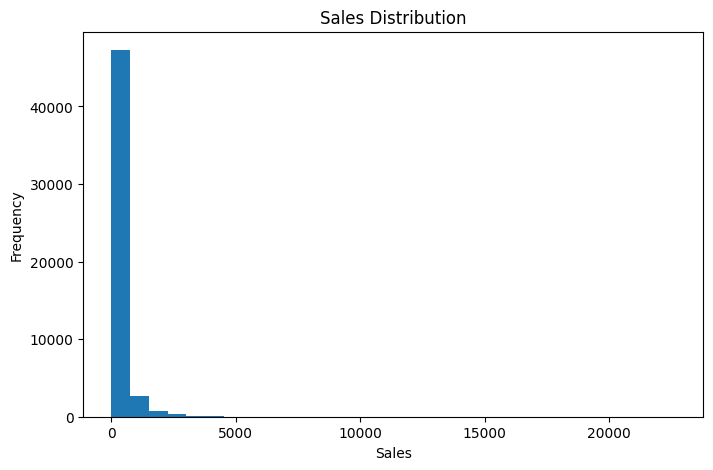

In [31]:
#Step 1: Sales Distribution Analysis
plt.figure(figsize=(8,5))
plt.hist(df['Sales'], bins=30)
plt.title('Sales Distribution')
plt.xlabel('Sales')
plt.ylabel('Frequency')
plt.show()

**Sales Distribution Insight:** The sales distribution is highly right-skewed.
Most transactions involve relatively low sales amounts, whereas a small number of transactions generate exceptionally high revenue.
This indicates that a limited number of large orders contribute disproportionately to overall sales performance.

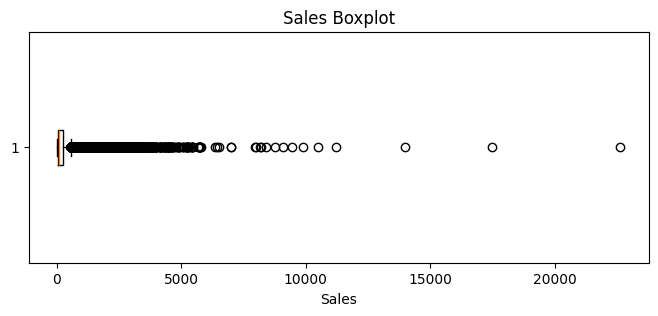

In [32]:
#Step 1: Sales Boxplot
plt.figure(figsize=(8,3))
plt.boxplot(df['Sales'], vert=False)
plt.title('Sales Boxplot')
plt.xlabel('Sales')
plt.show()

**Sales Boxplot Insight:** The sales data contains numerous high-value outliers, indicating that while most orders are relatively small, a limited number of transactions contribute exceptionally high sales amounts. These outliers likely represent major purchases and are important from a business perspective rather than data errors.

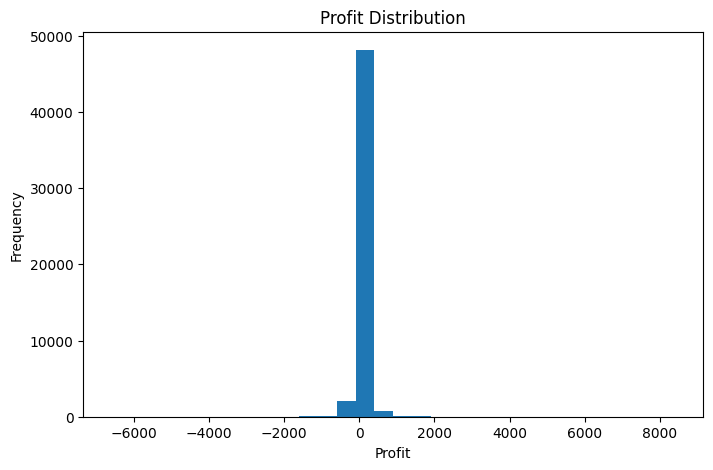

In [33]:
#Next Step 2: Profit Distribution Analysis
plt.figure(figsize=(8,5))
plt.hist(df['Profit'], bins=30)
plt.title('Profit Distribution')
plt.xlabel('Profit')
plt.ylabel('Frequency')
plt.show()

**Profit Distribution Insight** :Profit values are concentrated around zero, indicating that most transactions generate relatively small profits. However, the presence of both extreme losses and extreme gains suggests that certain business conditions—such as high discounts or specific products—can significantly impact profitability.

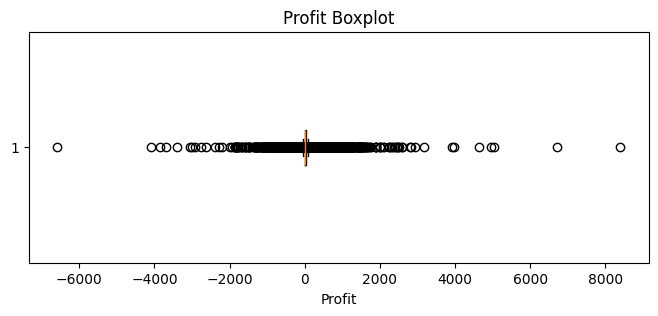

In [34]:
#profit BOXPLOT
plt.figure(figsize=(8,3))
plt.boxplot(df['Profit'], vert=False)
plt.title('Profit Boxplot')
plt.xlabel('Profit')
plt.show()

***Profit Boxplot Insight***: The profit distribution contains both substantial negative and positive outliers. While most transactions generate modest profits, a small number of orders contribute disproportionately large gains or losses. These extreme cases should be monitored closely to identify opportunities for improving profitability and reducing financial risk.

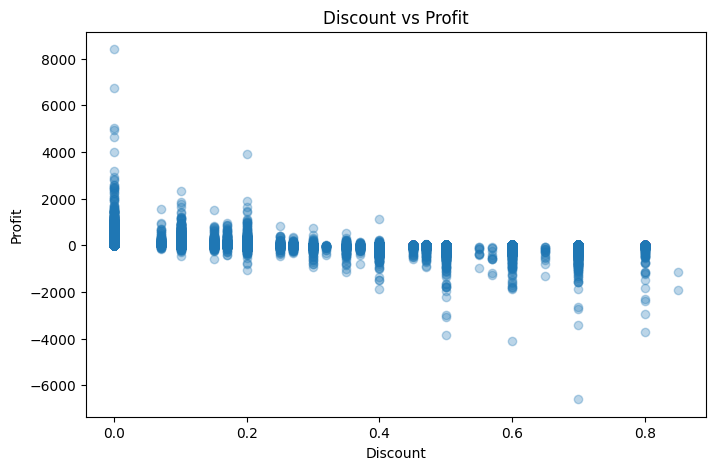

In [36]:
#Next Step 3: Discount vs Profit Analysis
plt.figure(figsize=(8,5))
plt.scatter(df['Discount'], df['Profit'], alpha=0.3)
plt.title('Discount vs Profit')
plt.xlabel('Discount')
plt.ylabel('Profit')
plt.show()

**Discount vs Profit Insight**: The scatter plot demonstrates a clear downward trend between discount and profit. Transactions with low discounts generally produce positive profits, whereas higher discount levels are increasingly associated with reduced profitability and substantial losses. This finding reinforces the need for careful discount management.

**Step 4:Correlation Heatmap**

Business Question

We want to understand:

Does discount reduce profit?



*  Does discount reduce profit?
*  Does higher quantity increase sales?

*  Are delivery days related to profit?
*  Which variables move together?



In [37]:
#Cell 1: Select Numerical Columns
corr_data = df[['Sales',
                'Profit',
                'Quantity',
                'Discount',
                'Delivery Days',
                'Shipping Cost']]

corr_data.head()

,Sales,Profit,Quantity,Discount,Delivery Days,Shipping Cost
0,2309.7,762.2,7,0.0,0,933.6
1,3709.4,-288.8,9,0.1,2,923.6
2,5175.2,920.0,9,0.1,1,915.5
3,2892.5,-96.5,5,0.1,2,910.2
4,2833.0,311.5,8,0.0,1,903.0


In [38]:
#Cell 2: Calculate Correlation Matrix
corr_matrix = corr_data.corr()
corr_matrix

,Sales,Profit,Quantity,Discount,Delivery Days,Shipping Cost
Sales,1.000000,0.484919,0.313576,-0.086782,-0.004659,0.768072
Profit,0.484919,1.000000,0.104366,-0.316507,0.001745,0.354441
Quantity,0.313576,0.104366,1.000000,-0.019876,0.004347,0.272650
Discount,-0.086782,-0.316507,-0.019876,1.000000,-0.001511,-0.079106
Delivery Days,-0.004659,0.001745,0.004347,-0.001511,1.000000,-0.142821
Shipping Cost,0.768072,0.354441,0.272650,-0.079106,-0.142821,1.000000


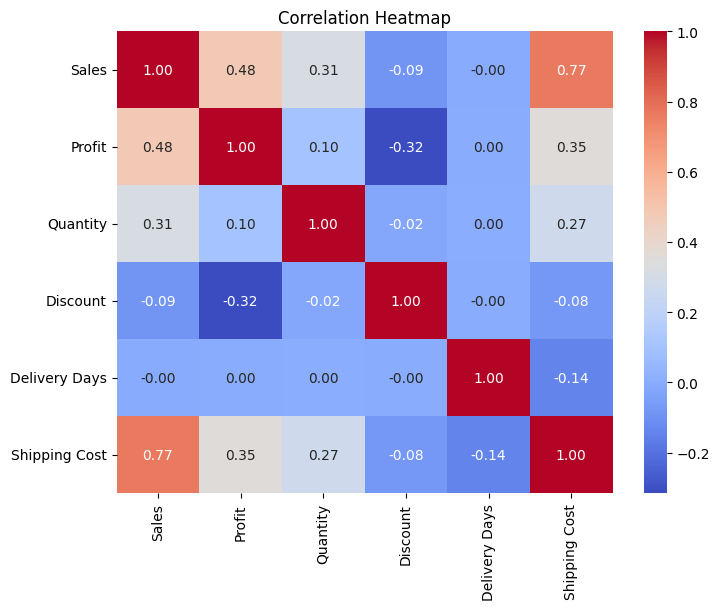

In [39]:
#Cell 3: Plot the Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(corr_matrix,
            annot=True,
            cmap='coolwarm',
            fmt='.2f')

plt.title('Correlation Heatmap')
plt.show()

The correlation analysis revealed that Sales and Profit share a moderate positive relationship (0.48), indicating that higher sales generally contribute to profitability. Discount exhibited a moderate negative correlation with Profit (-0.32), reinforcing earlier findings that excessive discounting reduces earnings. Sales and Shipping Cost demonstrated a strong positive relationship (0.77), suggesting that larger transactions incur higher logistics expenses. Delivery Days showed virtually no correlation with Profit, indicating that delivery speed is not a key profitability driver.

***Python Session 2: Customer Segmentation using K-Means***

In [46]:
#Step 1: Create a Customer-Level Dataset
customer_df = df.groupby(['Customer ID', 'Customer Name']).agg({
    'Sales': 'sum',
    'Profit': 'sum',
    'Order ID': 'nunique'
}).reset_index()

customer_df.rename(columns={
    'Sales': 'Revenue',
    'Order ID': 'Orders'
}, inplace=True)

customer_df.head()

,Customer ID,Customer Name,Revenue,Profit,Orders
0,AA-10315,Alex Avila,13747.6,447.8,19
1,AA-10375,Allen Armold,5884.3,677.7,23
2,AA-10480,Andrew Allen,17695.6,1516.3,20
3,AA-10645,Anna Andreadi,15344.3,3051.1,36
4,AA-315,Alex Avila,2243.2,535.6,7


In [47]:
customer_df.shape

(1590, 5)

In [51]:
#Step 3: Feature Scaling

from sklearn.preprocessing import StandardScaler
#Select Features

features = customer_df[['Revenue', 'Profit', 'Orders']]

#Scale Them
scaler = StandardScaler()

scaled_features = scaler.fit_transform(features)

In [52]:
scaled_features[:5]

array([[ 0.83586261, -0.3577882 ,  0.26405254],
       [-0.29808416, -0.18466974,  0.64084729],
       [ 1.40519379,  0.4468098 ,  0.35825123],
       [ 1.06611871,  1.60253933,  1.86543022],
       [-0.82315806, -0.29167336, -0.86633169]])

In [53]:
#Step 4: Elbow Method
from sklearn.cluster import KMeans

inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k,
                    random_state=42,
                    n_init=10)

    kmeans.fit(scaled_features)

    inertia.append(kmeans.inertia_)

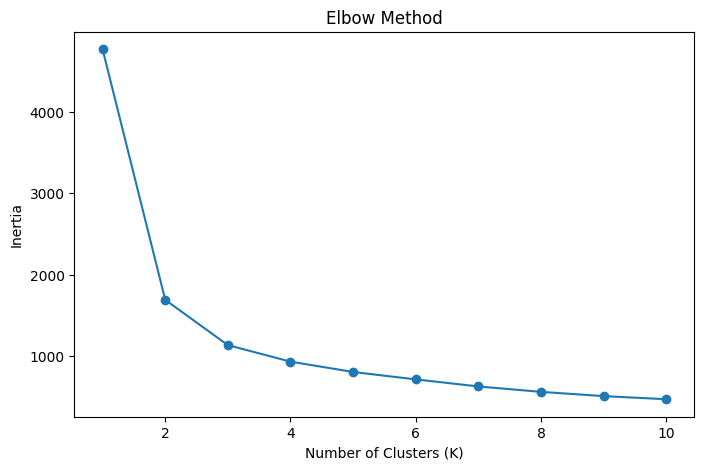

In [54]:
#Plot the Elbow Curve
plt.figure(figsize=(8,5))

plt.plot(range(1,11),
         inertia,
         marker='o')

plt.title('Elbow Method')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')

plt.show()

In [55]:
#Step 5: Apply K-Means
kmeans = KMeans(
    n_clusters=3,
    random_state=42,
    n_init=10
)

customer_df['Cluster'] = kmeans.fit_predict(scaled_features)

customer_df.head()

,Customer ID,Customer Name,Revenue,Profit,Orders,Cluster
0,AA-10315,Alex Avila,13747.6,447.8,19,1
1,AA-10375,Allen Armold,5884.3,677.7,23,1
2,AA-10480,Andrew Allen,17695.6,1516.3,20,1
3,AA-10645,Anna Andreadi,15344.3,3051.1,36,2
4,AA-315,Alex Avila,2243.2,535.6,7,0


In [56]:
#Step 6: Understand the Clusters
customer_df.groupby('Cluster')[['Revenue','Profit','Orders']].mean()

,Revenue,Profit,Orders
Cluster,,,
0,2170.425862,167.833005,6.573892
1,12003.991877,1103.011011,25.178700
2,18884.151339,3214.848661,28.866071


In [57]:
#Step 7: Name the Clusters
segment_map = {
    0: 'Low Value',
    1: 'Regular',
    2: 'High Value'
}

customer_df['Segment_Type'] = customer_df['Cluster'].map(segment_map)

customer_df.head()

,Customer ID,Customer Name,Revenue,Profit,Orders,Cluster,Segment_Type
0,AA-10315,Alex Avila,13747.6,447.8,19,1,Regular
1,AA-10375,Allen Armold,5884.3,677.7,23,1,Regular
2,AA-10480,Andrew Allen,17695.6,1516.3,20,1,Regular
3,AA-10645,Anna Andreadi,15344.3,3051.1,36,2,High Value
4,AA-315,Alex Avila,2243.2,535.6,7,0,Low Value


In [58]:
customer_df['Segment_Type'].value_counts()

,count
Segment_Type,
Low Value,812
Regular,554
High Value,224


In [59]:
customer_df.to_csv('customer_segments.csv', index=False)

In [61]:
#Export for Power BI Finally, save the dataset:
customer_df.to_csv('customer_segments.csv', index=False)